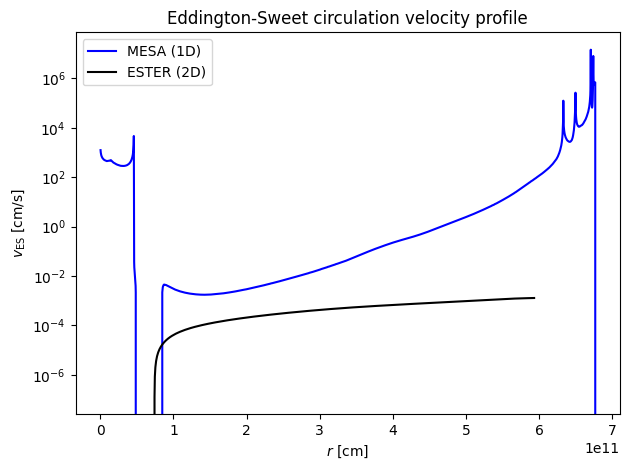

MESA mean v_ES: 89976.9272515976


In [ ]:
!pip install mesa_reader

import matplotlib.pyplot as plt
import mesa_reader as mr
import h5py

# Philip Mocz, 2025

# Plot the Eddington-Sweet circulation velocity of your MESA run
# and compare it to the 2D ESTER model

# Before you run this script, make sure to:

# 1. Upload into /contents/ the ESTER reference run provided
# 2. Upload into /contents/ the results of your MESA run


# Load the MESA profile data
load_dir = mr.MesaLogDir("/content")
profile = load_dir.profile_data()
# (by default, if profile_number is not specified, mesa_reader loads the last profile)

mesa_r = 10**profile.logR * profile.rsun
mesa_vr = profile.v_ES

# Load the ESTER model data (we will need 'vr')
ester_file = ("/content/M10_O60_X071Z200_evol_viscv1e7_visc_h1e7_delta010_2_0025.h5")
MYR = 3.15576e13
ester = h5py.File(ester_file, "r")
ester_R = ester["star"].attrs["R"]
ester_r = ester["star"]["r"][-1] * ester_R
ester_vr = ester["star"]["vr"][-1] * ester_R / MYR

# Plot the Eddington-Sweet circulation velocity
plt.figure()
plt.plot(mesa_r, mesa_vr, label="MESA (1D)", color="blue")
plt.plot(ester_r, ester_vr, label="ESTER (2D)", color="black")
plt.xlabel(r"$r$ [cm]")
plt.ylabel(r"$v_{\rm ES}$ [cm/s]")
plt.title("Eddington-Sweet circulation velocity profile")
plt.yscale("log")
plt.legend()
plt.tight_layout()
#plt.savefig("eddington_sweet_velocity.png", bbox_inches="tight", pad_inches=0)
plt.show()

# The mean Eddington-Sweet velocity is:
print("MESA mean v_ES:", mesa_vr.mean())